In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import math 
import os 
import re 
from sklearn.preprocessing import OneHotEncoder , LabelEncoder , OrdinalEncoder , RobustScaler
from sklearn.model_selection import train_test_split
os.chdir(R"D:\AI\Elvorix Diploma\2. Machine Learning\4. Day 4")
dataframe = pd.read_excel("Vehicle_Price_Fresh_Dataset.xlsx")
df = dataframe.copy()
df.head(3)
# Show duplicated data 
print("The Summation of Duplicated Data ==> ", df.duplicated().sum())
#drop the duplicated data 
df.drop_duplicates(inplace=True)
print("The data after drop duplicated data are ==> ",df.duplicated().sum())
print("======="*10)
print("The Data Information are : ")
print("======="*10)
df.info()

The Summation of Duplicated Data ==>  24
The data after drop duplicated data are ==>  0
The Data Information are : 
<class 'pandas.DataFrame'>
Index: 978 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            978 non-null    str    
 1   description     926 non-null    str    
 2   make            978 non-null    str    
 3   model           978 non-null    object 
 4   year            978 non-null    int64  
 5   price           955 non-null    float64
 6   engine          976 non-null    str    
 7   cylinders       875 non-null    float64
 8   fuel            971 non-null    str    
 9   mileage         946 non-null    float64
 10  transmission    976 non-null    str    
 11  trim            977 non-null    str    
 12  body            975 non-null    str    
 13  doors           971 non-null    float64
 14  exterior_color  973 non-null    str    
 15  interior_color  940 non-

In [9]:
# Show The Null Values 
print("The Percentage of Null Values in the Data are : ", df.isnull().sum() / len(df) * 100)
print("======================================================================")
print("The Values count for Null Values in data are :\n ",df.isnull().sum().sort_values(ascending=False))

The Percentage of Null Values in the Data are :  name               0.000000
description        5.316973
make               0.000000
model              0.000000
year               0.000000
price              2.351738
engine             0.204499
cylinders         10.531697
fuel               0.715746
mileage            3.271984
transmission       0.204499
trim               0.102249
body               0.306748
doors              0.715746
exterior_color     0.511247
interior_color     3.885481
drivetrain         0.000000
dtype: float64
The Values count for Null Values in data are :
  cylinders         103
description        52
interior_color     38
mileage            32
price              23
fuel                7
doors               7
exterior_color      5
body                3
engine              2
transmission        2
trim                1
name                0
model               0
make                0
year                0
drivetrain          0
dtype: int64


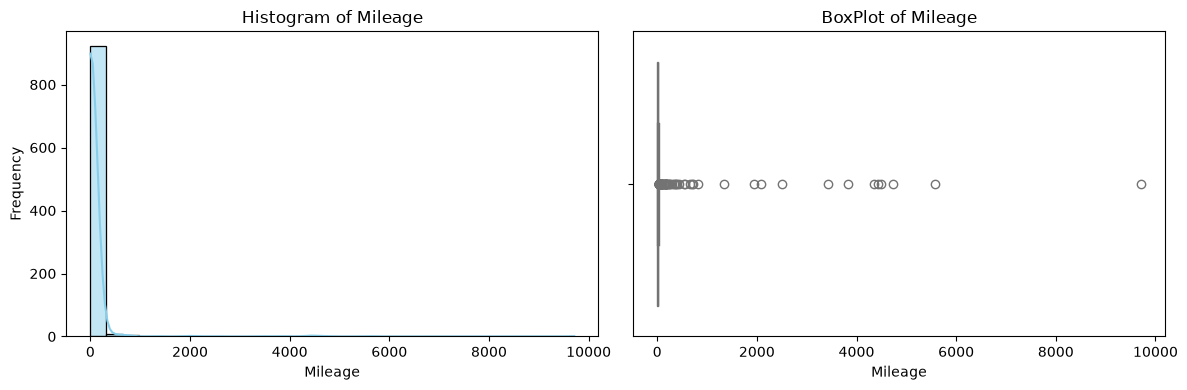

In [10]:
#Creating a function to Visualize the Null Values in the Data
def plot_hist_box(column_data,column_name=None):
    if column_name is None : column_name = column_data.name 
    plt.figure(figsize=(12,4))
    #Histogram 
    plt.subplot(1,2,1)
    sns.histplot(column_data,kde=True,bins=30,color='skyblue')
    plt.title(f"Histogram of {column_name}")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    #Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=column_data,color='lightgreen')
    plt.title(f"BoxPlot of {column_name}")
    plt.xlabel(column_name)
    
    plt.tight_layout()
    plt.show()
plot_hist_box(df['mileage'], 'Mileage')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'Jeep'),
  Text(1, 0, 'GMC'),
  Text(2, 0, 'Dodge'),
  Text(3, 0, 'RAM'),
  Text(4, 0, 'Nissan'),
  Text(5, 0, 'Ford'),
  Text(6, 0, 'Hyundai'),
  Text(7, 0, 'Chevrolet'),
  Text(8, 0, 'Volkswagen'),
  Text(9, 0, 'Chrysler'),
  Text(10, 0, 'Kia'),
  Text(11, 0, 'Mazda'),
  Text(12, 0, 'Acura'),
  Text(13, 0, 'Subaru'),
  Text(14, 0, 'Audi'),
  Text(15, 0, 'BMW'),
  Text(16, 0, 'Toyota'),
  Text(17, 0, 'Buick'),
  Text(18, 0, 'Mercedes-Benz'),
  Text(19, 0, 'Honda'),
  Text(20, 0, 'Lincoln'),
  Text(21, 0, 'Cadillac'),
  Text(22, 0, 'INFINITI'),
  Text(23, 0, 'Lexus'),
  Text(24, 0, 'Land Rover'),
  Text(25, 0, 'Volvo'),
  Text(26, 0, 'Genesis'),
  Text(27, 0, 'Jaguar')])

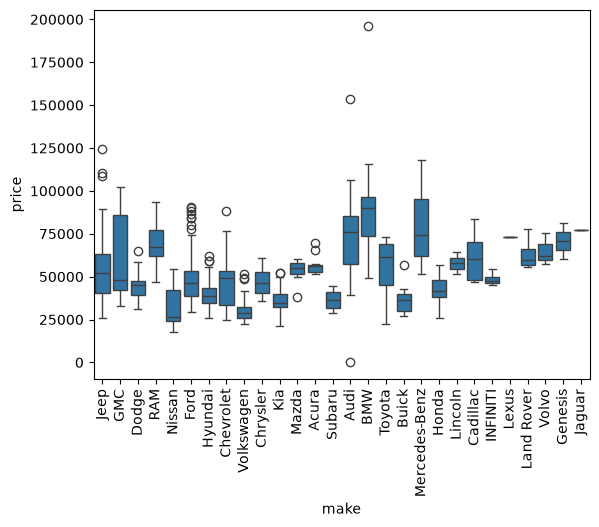

In [13]:
# Handeling Null Values 
'''First Column for handling Null Values [Mileage]'''
df['mileage'] = df['mileage'].fillna(df['mileage'].median())
'''First Column for handling Null Values [Price]'''
data = df.dropna(subset=['price']) 
# تم اخذ نسخة من الداتا والسبب في هذا ان في بعض الاعمدة سوف يتم القيام بحذفهم 
data['fuel'] = data['fuel'].fillna(data['fuel'].mode()[0])
data.groupby('make')['cylinders'].value_counts().reset_index(name='count')
#Cylinders 
cylinder_mode_per_make = data.groupby('make')['cylinders'].apply(lambda x:x.mode()).droplevel(level=None).to_dict()
data['cylinders'] = data['cylinders'].fillna(data['make'].map(cylinder_mode_per_make)).fillna(4)
#Interior Color 
data['interior_color'] = data['interior_color'].fillna(data['interior_color'].mode()[0])
#doors 
data['doors'] = data['doors'].fillna(data['doors'].mode()[0])
#Exterior Color 
data['exterior_color'] = data['exterior_color'].fillna(data['exterior_color'].mode()[0])
#=======================================================================================================
'''Drop Some Columns from the data like Transmission , trim , body , engine'''
data=data.dropna(subset=['transmission','trim','body','engine'])
#Visualize for data after drop 
sns.boxplot(x='make',y='price',data=data)
plt.xticks(rotation=90)

In [20]:
#splitting data by using variables 
x = data.drop(columns='price')
y = data['price']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)
print(f"The X train Shape are ==> {x_train.shape}")
print(f"The X Test Shape are ==> {x_test.shape}")
# Check Categorrical columns 
categorical_columns = x_train.select_dtypes(include='object').columns.tolist()
categorical_columns
# Check unique values 
for col in categorical_columns:
    print(col)
    print(x_train[col].value_counts())
    print("======="*20)

The X train Shape are ==> (757, 12)
The X Test Shape are ==> (190, 12)
make
make
Jeep             151
Hyundai          101
Dodge             78
Ford              67
RAM               56
Chevrolet         42
Kia               41
Nissan            31
Mazda             28
Volkswagen        27
Mercedes-Benz     21
BMW               16
Honda             15
GMC               15
Audi              12
Cadillac           9
Chrysler           8
Subaru             8
Acura              7
Buick              6
Toyota             5
INFINITI           3
Land Rover         3
Volvo              2
Lincoln            2
Genesis            2
Lexus              1
Name: count, dtype: int64
model
model
Hornet             48
3500               37
Compass            34
Tucson Hybrid      26
Durango            25
                   ..
SQ8 e-tron          1
Ranger              1
Discovery Sport     1
AMG GLE 53          1
Sonata              1
Name: count, Length: 140, dtype: int64
engine
engine
16V GDI DOHC Turbo 

C:\Users\Alhou\AppData\Local\Temp\ipykernel_17708\271629980.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x_train.select_dtypes(include='object').columns.tolist()


In [24]:
#Apply Encoding  
oht_drivetrain = OneHotEncoder(handle_unknown = 'ignore',sparse_output=False)
encoded_values = oht_drivetrain.fit_transform(x_train[['drivetrain']])
encoded_cols = oht_drivetrain.get_feature_names_out().tolist()
print(encoded_cols)
print("=========================================================")
#Convert drivetrain data to datafeame 
encoded_df = pd.DataFrame(data=encoded_values,columns=encoded_cols,index=x_train.index)
encoded_df.head(3)

['drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive', 'drivetrain_Front-wheel Drive', 'drivetrain_Rear-wheel Drive']


,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
111,1.0,0.0,0.0,0.0
78,0.0,1.0,0.0,0.0
578,1.0,0.0,0.0,0.0


In [25]:
#Concatenate the encoded dataframe with the original x_train dataframe 
x_train = pd.concat([x_train,encoded_df],axis=1)
x_train.drop(columns='drivetrain',inplace =True)
x_train.head(3)
#Apply Ordinal 
cat_cols = x_train.select_dtypes(include='object').columns.tolist()
print("The Categorical Columns are : ",cat_cols)
print("=="*20)
columns_encoder = OrdinalEncoder()
x_train[['body','fuel','make']].head(3)

The Categorical Columns are :  ['make', 'model', 'engine', 'fuel', 'transmission', 'trim', 'body']


C:\Users\Alhou\AppData\Local\Temp\ipykernel_17708\164870565.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(include='object').columns.tolist()


,body,fuel,make
111,SUV,Hybrid,Hyundai
78,Pickup Truck,Diesel,RAM
578,SUV,Gasoline,Chevrolet


In [27]:
x_train[['body','fuel','make']] = columns_encoder.fit_transform(x_train[['body','fuel','make']])
x_train[['body','fuel','make']].head(3)

,body,fuel,make
111,6.0,4.0,12.0
78,5.0,0.0,22.0
578,6.0,3.0,5.0


In [28]:
for col,cat in zip(['body','fuel','make'],columns_encoder.categories_):
    print(f"Column : {col} , Categories : {cat}")
    for i,category in enumerate(cat):
        print(f"Category : {category} , Encoded Value : {i}")
    print("=="*20)

Column : body , Categories : ['Cargo Van' 'Convertible' 'Hatchback' 'Minivan' 'Passenger Van'
 'Pickup Truck' 'SUV' 'Sedan']
Category : Cargo Van , Encoded Value : 0
Category : Convertible , Encoded Value : 1
Category : Hatchback , Encoded Value : 2
Category : Minivan , Encoded Value : 3
Category : Passenger Van , Encoded Value : 4
Category : Pickup Truck , Encoded Value : 5
Category : SUV , Encoded Value : 6
Category : Sedan , Encoded Value : 7
Column : fuel , Categories : ['Diesel' 'E85 Flex Fuel' 'Electric' 'Gasoline' 'Hybrid'
 'PHEV Hybrid Fuel']
Category : Diesel , Encoded Value : 0
Category : E85 Flex Fuel , Encoded Value : 1
Category : Electric , Encoded Value : 2
Category : Gasoline , Encoded Value : 3
Category : Hybrid , Encoded Value : 4
Category : PHEV Hybrid Fuel , Encoded Value : 5
Column : make , Categories : ['Acura' 'Audi' 'BMW' 'Buick' 'Cadillac' 'Chevrolet' 'Chrysler' 'Dodge'
 'Ford' 'GMC' 'Genesis' 'Honda' 'Hyundai' 'INFINITI' 'Jeep' 'Kia'
 'Land Rover' 'Lexus' 'Linc

<Axes: xlabel='price', ylabel='Density'>

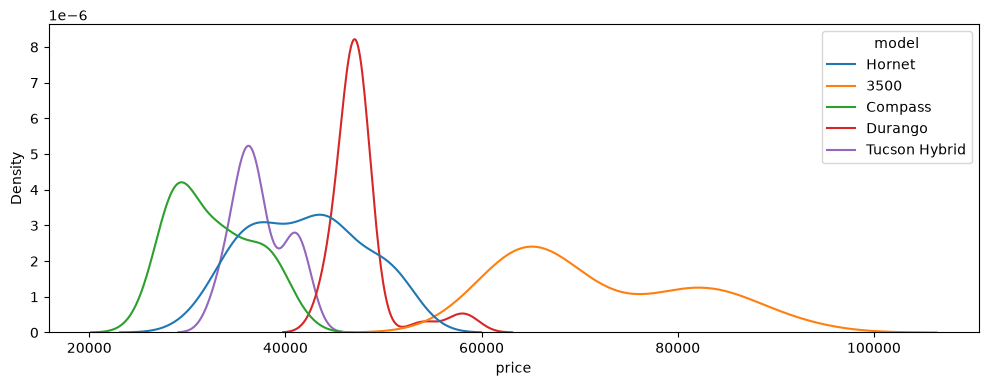

In [29]:
#Visualize for check columns effects on the price column
plt.figure(figsize=(12,4))
sns.kdeplot(data=data,x="price",hue='model',hue_order=data['model'].value_counts().index[:5])

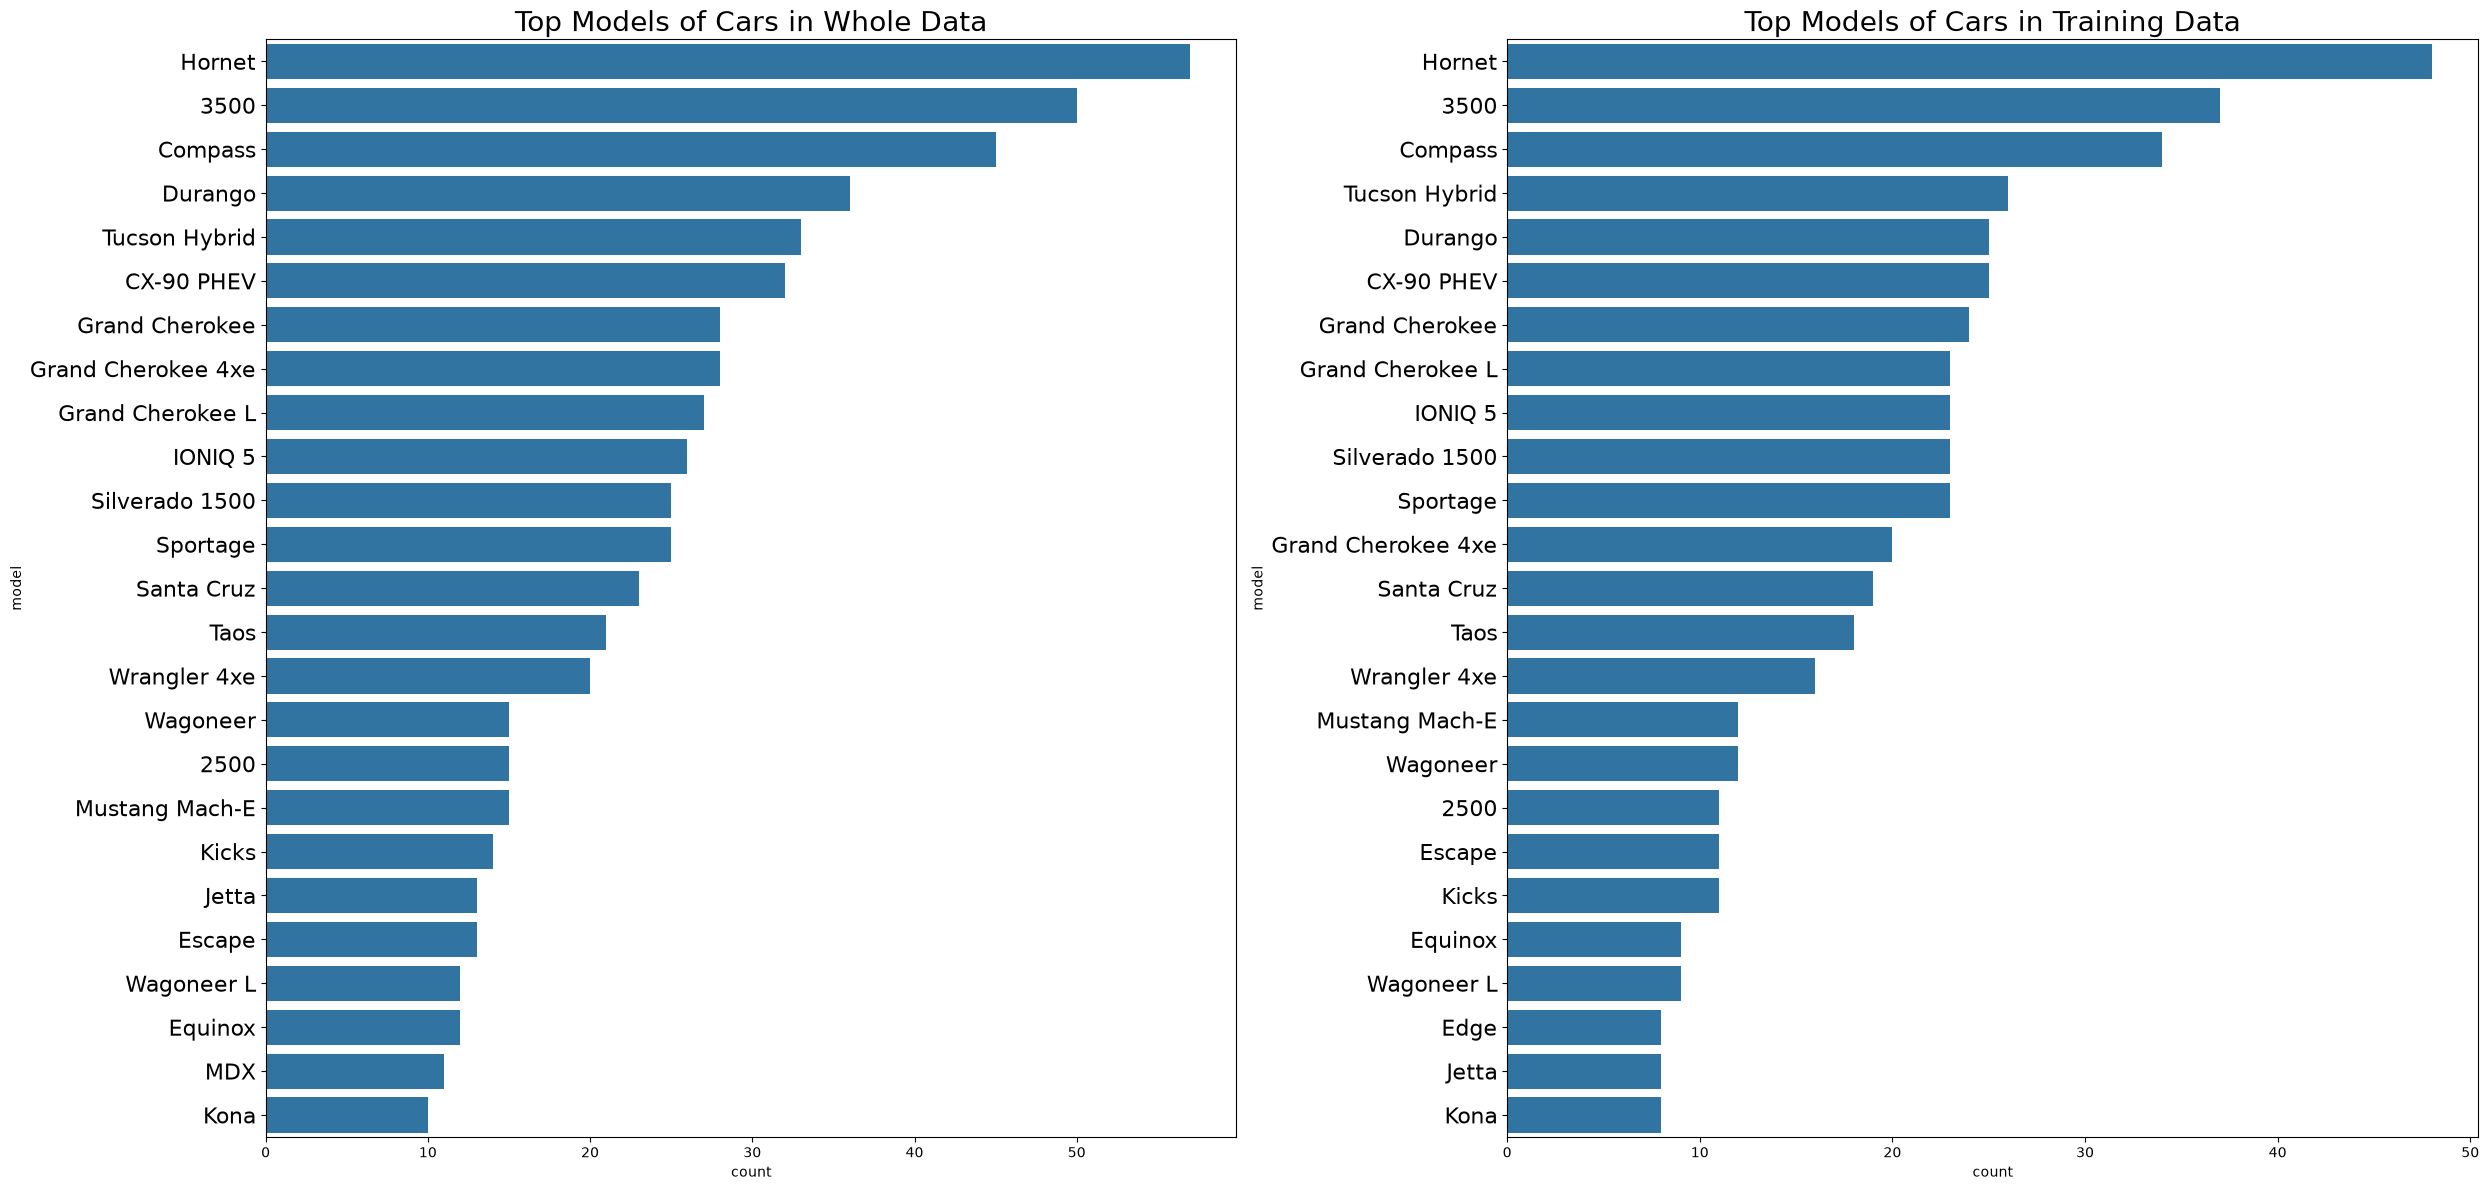

In [30]:
plt.figure(figsize=(25, 12))

# First subplot
plt.subplot(1, 2, 1)
sns.countplot(data=data, y='model', order=data['model'].value_counts().index[:25])
plt.yticks(fontsize=16)
plt.title('Top Models of Cars in Whole Data', fontsize=20)

# Second subplot
plt.subplot(1, 2, 2)
sns.countplot(data=x_train, y='model', order=x_train['model'].value_counts().index[:25])
plt.yticks(fontsize=16)
plt.title('Top Models of Cars in Training Data', fontsize=20)

plt.tight_layout();

In [31]:
top_models= x_train['model'].value_counts().nlargest(25).index
x_train['model']=x_train['model'].where(x_train['model'].isin(top_models),'other')
x_train['model']

111       Tucson Hybrid
78                 3500
578             Equinox
893               other
84     Grand Cherokee L
             ...       
108             Compass
278          CX-90 PHEV
911            Sportage
455                2500
104      Silverado 1500
Name: model, Length: 757, dtype: object

In [32]:
# Apply feature engineering 
x_train['engine']= x_train['engine'].astype(str).str.lower() # First convert data to lowercase 
# Extract features from engine column
x_train['is_turbo'] = x_train['engine'].apply(lambda x:1 if 'turbo' in x or 'ecoboost' in x else 0)
x_train['is_hybrid'] = x_train['engine'].apply(lambda x:1 if 'hybrid' in x else 0)
x_train['is_diesel'] = x_train['engine'].apply(lambda x:1 if 'diesel' in x else 0)

#Extract the valve type from engine column
def get_valve_type(text):
    if 'dohc' in text: return 'DOHC'
    if 'ohv' in text: return 'OHV'
    if 'sohc' in text: return 'SOHC'
    return 'Other' # For corrupted texts and VIN codes
x_train['valve_type'] = x_train['engine'].apply(get_valve_type)

In [33]:
def extract_engine_features(engine_str):
    engine_str = str(engine_str).lower()  # Convert to lowercase for consistency
    return {
        "is_v6" : int('v-6' in engine_str or '3.61' in engine_str),
        "is_v8" : int('v-8' in engine_str or '5.0' in engine_str),
        "is_i4" : int('i-4' in engine_str or '2.01' in engine_str),
        "is_turbo" : int('turbo' in engine_str),
        'is_hybrid': int('hybrid' in engine_str),
        'is_diesel': int('diesel' in engine_str),
        'is_electric': int('electric' in engine_str or 'zev' in engine_str or 'ev' in engine_str),
        'valves_16v': int('16v' in engine_str),
        'valves_24v': int('24v' in engine_str),
        'valves_12v': int('12v' in engine_str),
        'is_dohc': int('dohc' in engine_str),
        'is_sohc': int('sohc' in engine_str),
        'is_ohv': int('ohv' in engine_str),
        'has_vvt': int('vvt' in engine_str)
    }
x_train['engine'].apply(extract_engine_features).apply(pd.Series)

,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,0,0,0,1,1,0,0,1,0,0,1,0,0,0
78,0,0,0,1,0,1,0,0,1,0,0,0,1,0
578,0,0,0,0,0,0,0,0,0,0,1,0,0,0
893,0,0,0,0,0,0,0,0,0,0,0,0,0,0
84,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,0,0,0,0,0,0,0,0,0,0,1,0,0,0
278,0,0,0,0,0,0,1,1,0,0,1,0,0,0
911,0,0,0,0,0,0,0,1,0,0,1,0,0,0
455,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [34]:
engine_features_train = x_train['engine'].apply(extract_engine_features).apply(pd.Series)
engine_features_train.head(3)

,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,0,0,0,1,1,0,0,1,0,0,1,0,0,0
78,0,0,0,1,0,1,0,0,1,0,0,0,1,0
578,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [35]:
x_train = pd.concat([x_train,engine_features_train],axis=1)
x_train = x_train.drop(columns=['engine'])
x_train.head(3)

,make,model,year,cylinders,fuel,mileage,transmission,trim,body,doors,...,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,12.0,Tucson Hybrid,2024,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,...,1,0,0,1,0,0,1,0,0,0
78,22.0,3500,2024,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,...,0,1,0,0,1,0,0,0,1,0
578,5.0,Equinox,2024,4.0,3.0,3.0,Automatic,LS,6.0,4.0,...,0,0,0,0,0,0,1,0,0,0


In [36]:
# To show all columns
pd.set_option('display.max_columns', None)
x_train.head(3)

,make,model,year,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,12.0,Tucson Hybrid,2024,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0
78,22.0,3500,2024,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0
578,5.0,Equinox,2024,4.0,3.0,3.0,Automatic,LS,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [37]:
def extract_trans_type(transmission_str):
    transmission_str = str(transmission_str).lower()  # Convert to lowercase for consistency
    if 'manual' in transmission_str: return 'Manual'
    elif 'cvt' in transmission_str or 'variable' in transmission_str: return 'CVT'
    elif 'auto' in transmission_str or 'a/t' in transmission_str: return 'Automatic'
    else: return 'Other'
x_train['trans_type'] = x_train['transmission'].apply(extract_trans_type)
print(x_train['trans_type'].value_counts())
x_train.head(3)

trans_type
Automatic    711
CVT           45
Other          1
Name: count, dtype: int64


,make,model,year,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type
111,12.0,Tucson Hybrid,2024,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic
78,22.0,3500,2024,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic
578,5.0,Equinox,2024,4.0,3.0,3.0,Automatic,LS,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic


In [38]:
# I need to seperate number for speed 
# Used Regular Expression to extract the number from the string
import re
def extract_trans_speed(val):
    val = str(val).lower() 
    match = re.search(r'(\d+)[ -]?Speed',val,re.IGNORECASE)
    return int(match.group(1)) if match else -1 
x_train['trans_speed'] = x_train['transmission'].apply(extract_trans_speed)
x_train= x_train.drop(columns=['transmission']) #drop the transmission column after extracting the features
x_train.head(3)

,make,model,year,cylinders,fuel,mileage,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed
111,12.0,Tucson Hybrid,2024,4.0,4.0,5.0,SEL Convenience,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic,6
78,22.0,3500,2024,6.0,0.0,13.0,Tradesman,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic,-1
578,5.0,Equinox,2024,4.0,3.0,3.0,LS,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic,-1


In [39]:
# To Show all columns
x_train.columns

Index(['make', 'model', 'year', 'cylinders', 'fuel', 'mileage', 'trim', 'body',
       'doors', 'drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive',
       'drivetrain_Front-wheel Drive', 'drivetrain_Rear-wheel Drive',
       'is_turbo', 'is_hybrid', 'is_diesel', 'valve_type', 'is_v6', 'is_v8',
       'is_i4', 'is_turbo', 'is_hybrid', 'is_diesel', 'is_electric',
       'valves_16v', 'valves_24v', 'valves_12v', 'is_dohc', 'is_sohc',
       'is_ohv', 'has_vvt', 'trans_type', 'trans_speed'],
      dtype='str')

In [40]:
print("The Number of Unique Values in Trim Column are : ",x_train['trim'].nunique())
x_train['trim'].value_counts().nlargest(30)

The Number of Unique Values in Trim Column are :  171


trim
Limited            56
Base               42
SEL                28
Premium            24
Latitude           20
Pursuit            20
Tradesman          18
1.5T SE            15
Laredo             15
R/T Plus           13
GT                 13
SEL Convenience    12
SV                 11
LT                 11
Sport              11
R/T                11
S                  11
XLT                11
Series II          11
Laramie            10
Rubicon            10
SE                  9
GT AWD              9
EX                  9
Altitude            8
SR                  8
Trailhawk           8
X-Line              8
Premium Plus        7
Base 4MATIC         7
Name: count, dtype: int64

In [42]:
def simplify_trim(trim_str):
    trim = str(trim_str).lower()
    if 'sel' in trim: return 'SEL'
    elif 'gt' in trim: return 'GT'
    elif 'rt' in trim: return 'R/T'
    elif 'base' in trim: return 'Base'
    elif 'limited' in trim: return 'Limited'
    elif 'premium' in trim: return 'Premium'
    elif 'latitude' in trim: return 'Latitude'
    elif 'laredo' in trim: return 'Laredo'
    elif 'sport' in trim: return 'Sport'
    elif 'xlt' in trim: return 'XLT'
    elif 'laramie' in trim: return 'Laramie'
    elif 'sv' in trim: return 'SV'
    elif 'se' in trim: return 'SE'
    elif 'ex' in trim: return 'EX'
    elif 'trailhawk' in trim: return 'Trailhawk'
    else: return 'Other'
x_train['trim_simplified'] = x_train['trim'].apply(simplify_trim)
print("the Number of Unique Values in trim_simplified:", x_train['trim_simplified'].nunique())
#drop the original trim column after simplification
x_train = x_train.drop(columns=['trim'])
x_train.head()

the Number of Unique Values in trim_simplified: 15


,make,model,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified
111,12.0,Tucson Hybrid,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic,6,SEL
78,22.0,3500,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic,-1,Other
578,5.0,Equinox,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic,-1,Other
893,11.0,other,2025,4.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,Other,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CVT,-1,EX
84,14.0,Grand Cherokee L,2024,6.0,3.0,8.0,6.0,4.0,0.0,1.0,0.0,0.0,0,0,0,OHV,0,0,0,0,0,0,0,0,0,0,0,0,1,0,Automatic,8,Limited


In [43]:
pd.set_option('display.max_columns',None)
x_train.head()

,make,model,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified
111,12.0,Tucson Hybrid,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic,6,SEL
78,22.0,3500,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic,-1,Other
578,5.0,Equinox,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic,-1,Other
893,11.0,other,2025,4.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,Other,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CVT,-1,EX
84,14.0,Grand Cherokee L,2024,6.0,3.0,8.0,6.0,4.0,0.0,1.0,0.0,0.0,0,0,0,OHV,0,0,0,0,0,0,0,0,0,0,0,0,1,0,Automatic,8,Limited


In [44]:
# Encoding Categorical Data 
categorical_columns = x_train.select_dtypes(include='object').columns.tolist()
categorical_columns
x_train[categorical_columns]

C:\Users\Alhou\AppData\Local\Temp\ipykernel_17708\2477334010.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x_train.select_dtypes(include='object').columns.tolist()


,model,valve_type,trans_type,trim_simplified
111,Tucson Hybrid,DOHC,Automatic,SEL
78,3500,OHV,Automatic,Other
578,Equinox,DOHC,Automatic,Other
893,other,Other,CVT,EX
84,Grand Cherokee L,OHV,Automatic,Limited
...,...,...,...,...
108,Compass,DOHC,Automatic,Latitude
278,CX-90 PHEV,DOHC,Automatic,Premium
911,Sportage,DOHC,Automatic,Other
455,2500,OHV,Automatic,Other


In [46]:
x_train['model'] = x_train['model'].astype(str)
oht_model = OneHotEncoder(sparse_output=False)
encoded_values = oht_model.fit_transform(x_train[['model']])
encoded_cols = oht_model.get_feature_names_out().tolist()
#Convert model column to DataFrame
encoded_df = pd.DataFrame(data=encoded_values,columns=encoded_cols,index=x_train.index)
#Concatenate the encoded DataFrame with the original x_train DataFrame
x_train = pd.concat([x_train,encoded_df],axis=1)
#drop the original model column from the x_train DataFrame
x_train.drop(columns=['model'], inplace=True)
x_train.head(3)

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other
111,12.0,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic,6,SEL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
78,22.0,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic,-1,Other,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
578,5.0,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic,-1,Other,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
print(x_train.columns.tolist())

['make', 'year', 'cylinders', 'fuel', 'mileage', 'body', 'doors', 'drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive', 'drivetrain_Front-wheel Drive', 'drivetrain_Rear-wheel Drive', 'is_turbo', 'is_hybrid', 'is_diesel', 'valve_type', 'is_v6', 'is_v8', 'is_i4', 'is_turbo', 'is_hybrid', 'is_diesel', 'is_electric', 'valves_16v', 'valves_24v', 'valves_12v', 'is_dohc', 'is_sohc', 'is_ohv', 'has_vvt', 'trans_type', 'trans_speed', 'trim_simplified', 'model_2500', 'model_3500', 'model_CX-90 PHEV', 'model_Compass', 'model_Durango', 'model_Edge', 'model_Equinox', 'model_Escape', 'model_Grand Cherokee', 'model_Grand Cherokee 4xe', 'model_Grand Cherokee L', 'model_Hornet', 'model_IONIQ 5', 'model_Jetta', 'model_Kicks', 'model_Kona', 'model_Mustang Mach-E', 'model_Santa Cruz', 'model_Silverado 1500', 'model_Sportage', 'model_Taos', 'model_Tucson Hybrid', 'model_Wagoneer', 'model_Wagoneer L', 'model_Wrangler 4xe', 'model_other']


In [51]:
categorical_columns = x_train.select_dtypes(include='object').columns.tolist()
cols_encoder = OrdinalEncoder()
x_train[categorical_columns] = cols_encoder.fit_transform(x_train[categorical_columns])
x_train.head()

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other
111,12.0,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,0.0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0.0,6,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
78,22.0,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,1.0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0.0,-1,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
578,5.0,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.0,-1,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
893,11.0,2025,4.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,-1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
84,14.0,2024,6.0,3.0,8.0,6.0,4.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,8,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
for col in x_train.columns:
    try:
        sns.boxplot(x=x_train[col])
        plt.close()
        print(f"{col} ✅")
    except Exception as e:
        print(f"{col} ❌ --> {e}")

make ✅
year ✅
cylinders ✅
fuel ✅
mileage ✅
body ✅
doors ✅
drivetrain_All-wheel Drive ✅
drivetrain_Four-wheel Drive ✅
drivetrain_Front-wheel Drive ✅
drivetrain_Rear-wheel Drive ✅
is_turbo ❌ --> If using all scalar values, you must pass an index
is_hybrid ❌ --> If using all scalar values, you must pass an index
is_diesel ❌ --> If using all scalar values, you must pass an index
valve_type ✅
is_v6 ✅
is_v8 ✅
is_i4 ✅
is_turbo ❌ --> If using all scalar values, you must pass an index
is_hybrid ❌ --> If using all scalar values, you must pass an index
is_diesel ❌ --> If using all scalar values, you must pass an index
is_electric ✅
valves_16v ✅
valves_24v ✅
valves_12v ✅
is_dohc ✅
is_sohc ✅
is_ohv ✅
has_vvt ✅
trans_type ✅
trans_speed ✅
trim_simplified ✅
model_2500 ✅
model_3500 ✅
model_CX-90 PHEV ✅
model_Compass ✅
model_Durango ✅
model_Edge ✅
model_Equinox ✅
model_Escape ✅
model_Grand Cherokee ✅
model_Grand Cherokee 4xe ✅
model_Grand Cherokee L ✅
model_Hornet ✅
model_IONIQ 5 ✅
model_Jetta ✅
model_K

In [55]:
x_train = x_train.loc[:, ~x_train.columns.duplicated()]

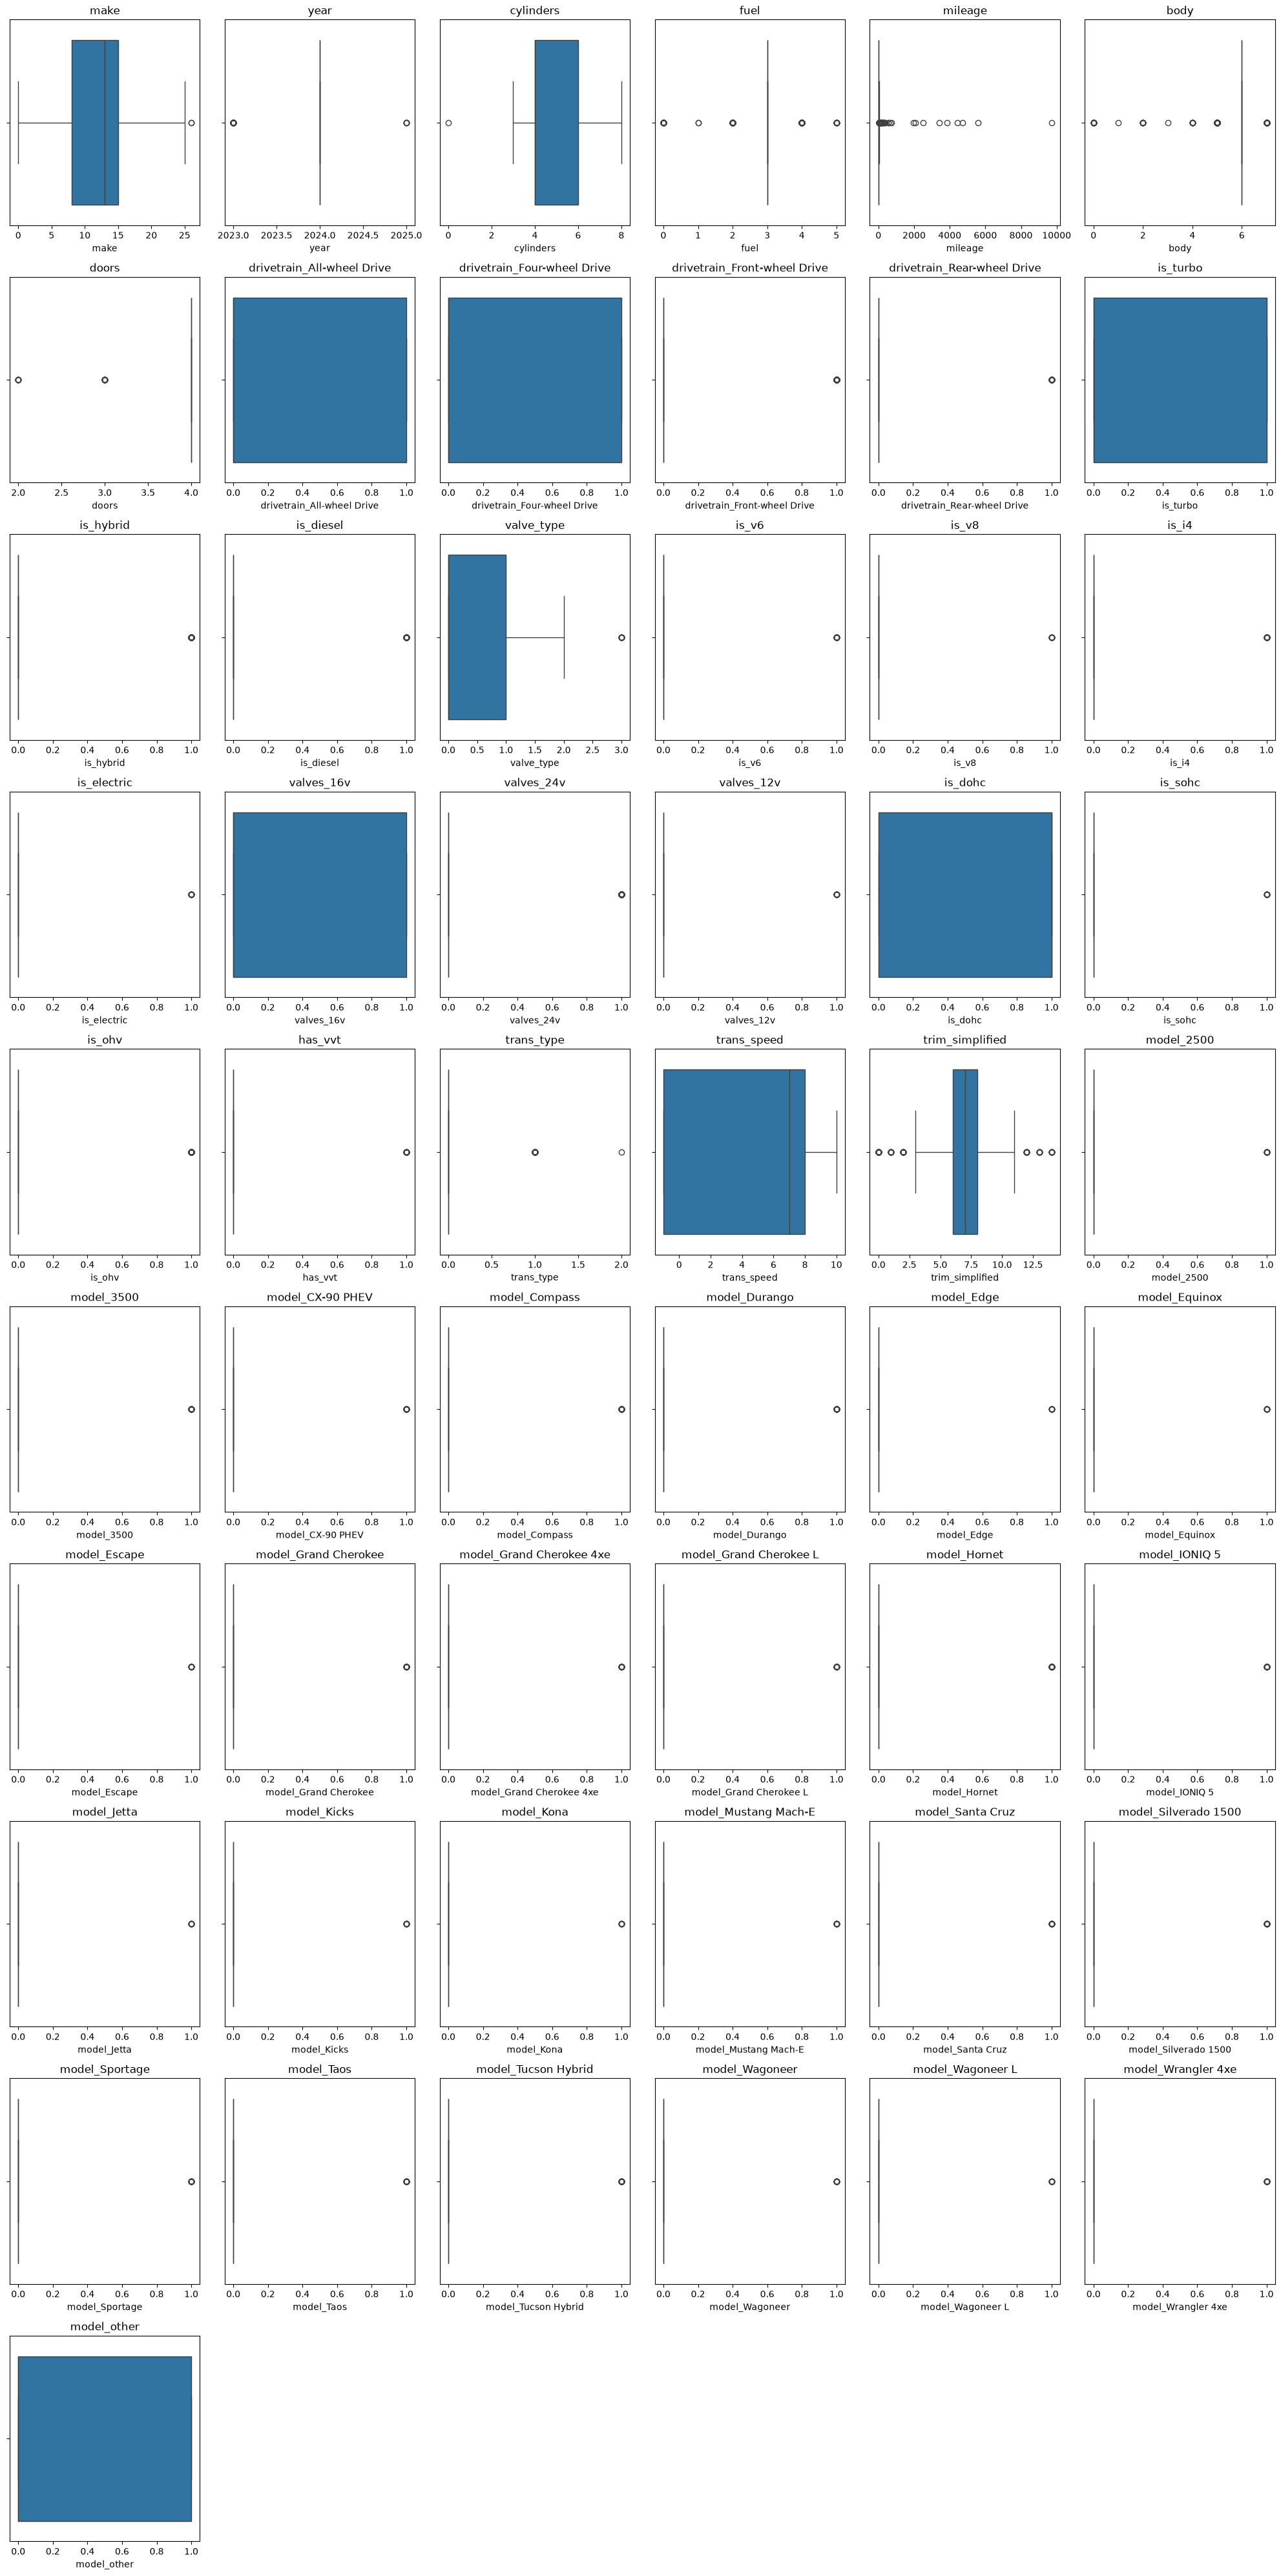

In [56]:
n_cols = 6
n_rows = math.ceil(len(x_train.columns) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
ax = ax.flatten()
for i, col in enumerate(x_train.columns):
    sns.boxplot(x=x_train[col], ax=ax[i])
    ax[i].set_title(col)
for j in range(len(x_train.columns), len(ax)):
    ax[j].set_visible(False)
plt.tight_layout()
plt.show()

In [57]:
# Take copy from data 
x_scaled = x_train.copy()
x_scaled.sample(5)

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other
552,25.0,2024,4.0,3.0,7.0,7.0,4.0,0.0,0.0,1.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,8,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
163,14.0,2023,6.0,3.0,0.0,5.0,4.0,0.0,1.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,1,0,1,0,0,0,0.0,8,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,7.0,2023,8.0,3.0,32.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,1.0,0,0,0,0,1,0,0,0,0,1,0,0.0,8,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
204,19.0,2024,4.0,5.0,8.0,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,1,1,0,0,1,0,0,0,0.0,-1,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
584,5.0,2024,8.0,3.0,2.0,5.0,4.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,1,0,0,0,0,1,0,0.0,10,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
from sklearn.preprocessing import RobustScaler
scalar = RobustScaler()
x_scaled[['year','cylinders','mileage','trans_speed']] = scalar.fit_transform(x_scaled[['year','cylinders','mileage','trans_speed']])
x_scaled

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other
111,12.0,0.0,0.0,4.0,-0.375,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,-0.111111,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
78,22.0,0.0,1.0,0.0,0.625,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,1.0,0,0,0,0,0,1,0,0,0,1,0,0.0,-0.888889,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
578,5.0,0.0,0.0,3.0,-0.625,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,-0.888889,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
893,11.0,1.0,0.0,3.0,-1.000,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,1.0,-0.888889,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
84,14.0,0.0,1.0,3.0,0.000,6.0,4.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1,0,0.0,0.111111,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,14.0,0.0,0.0,3.0,-0.875,6.0,4.0,0.0,1.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,-0.888889,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
278,19.0,0.0,0.0,5.0,0.125,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,1,1,0,0,1,0,0,0,0.0,-0.888889,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
911,15.0,0.0,0.0,3.0,-0.875,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,0.111111,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
455,22.0,0.0,2.0,3.0,-1.000,5.0,4.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,1,0,0,0,0,1,0,0.0,0.111111,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


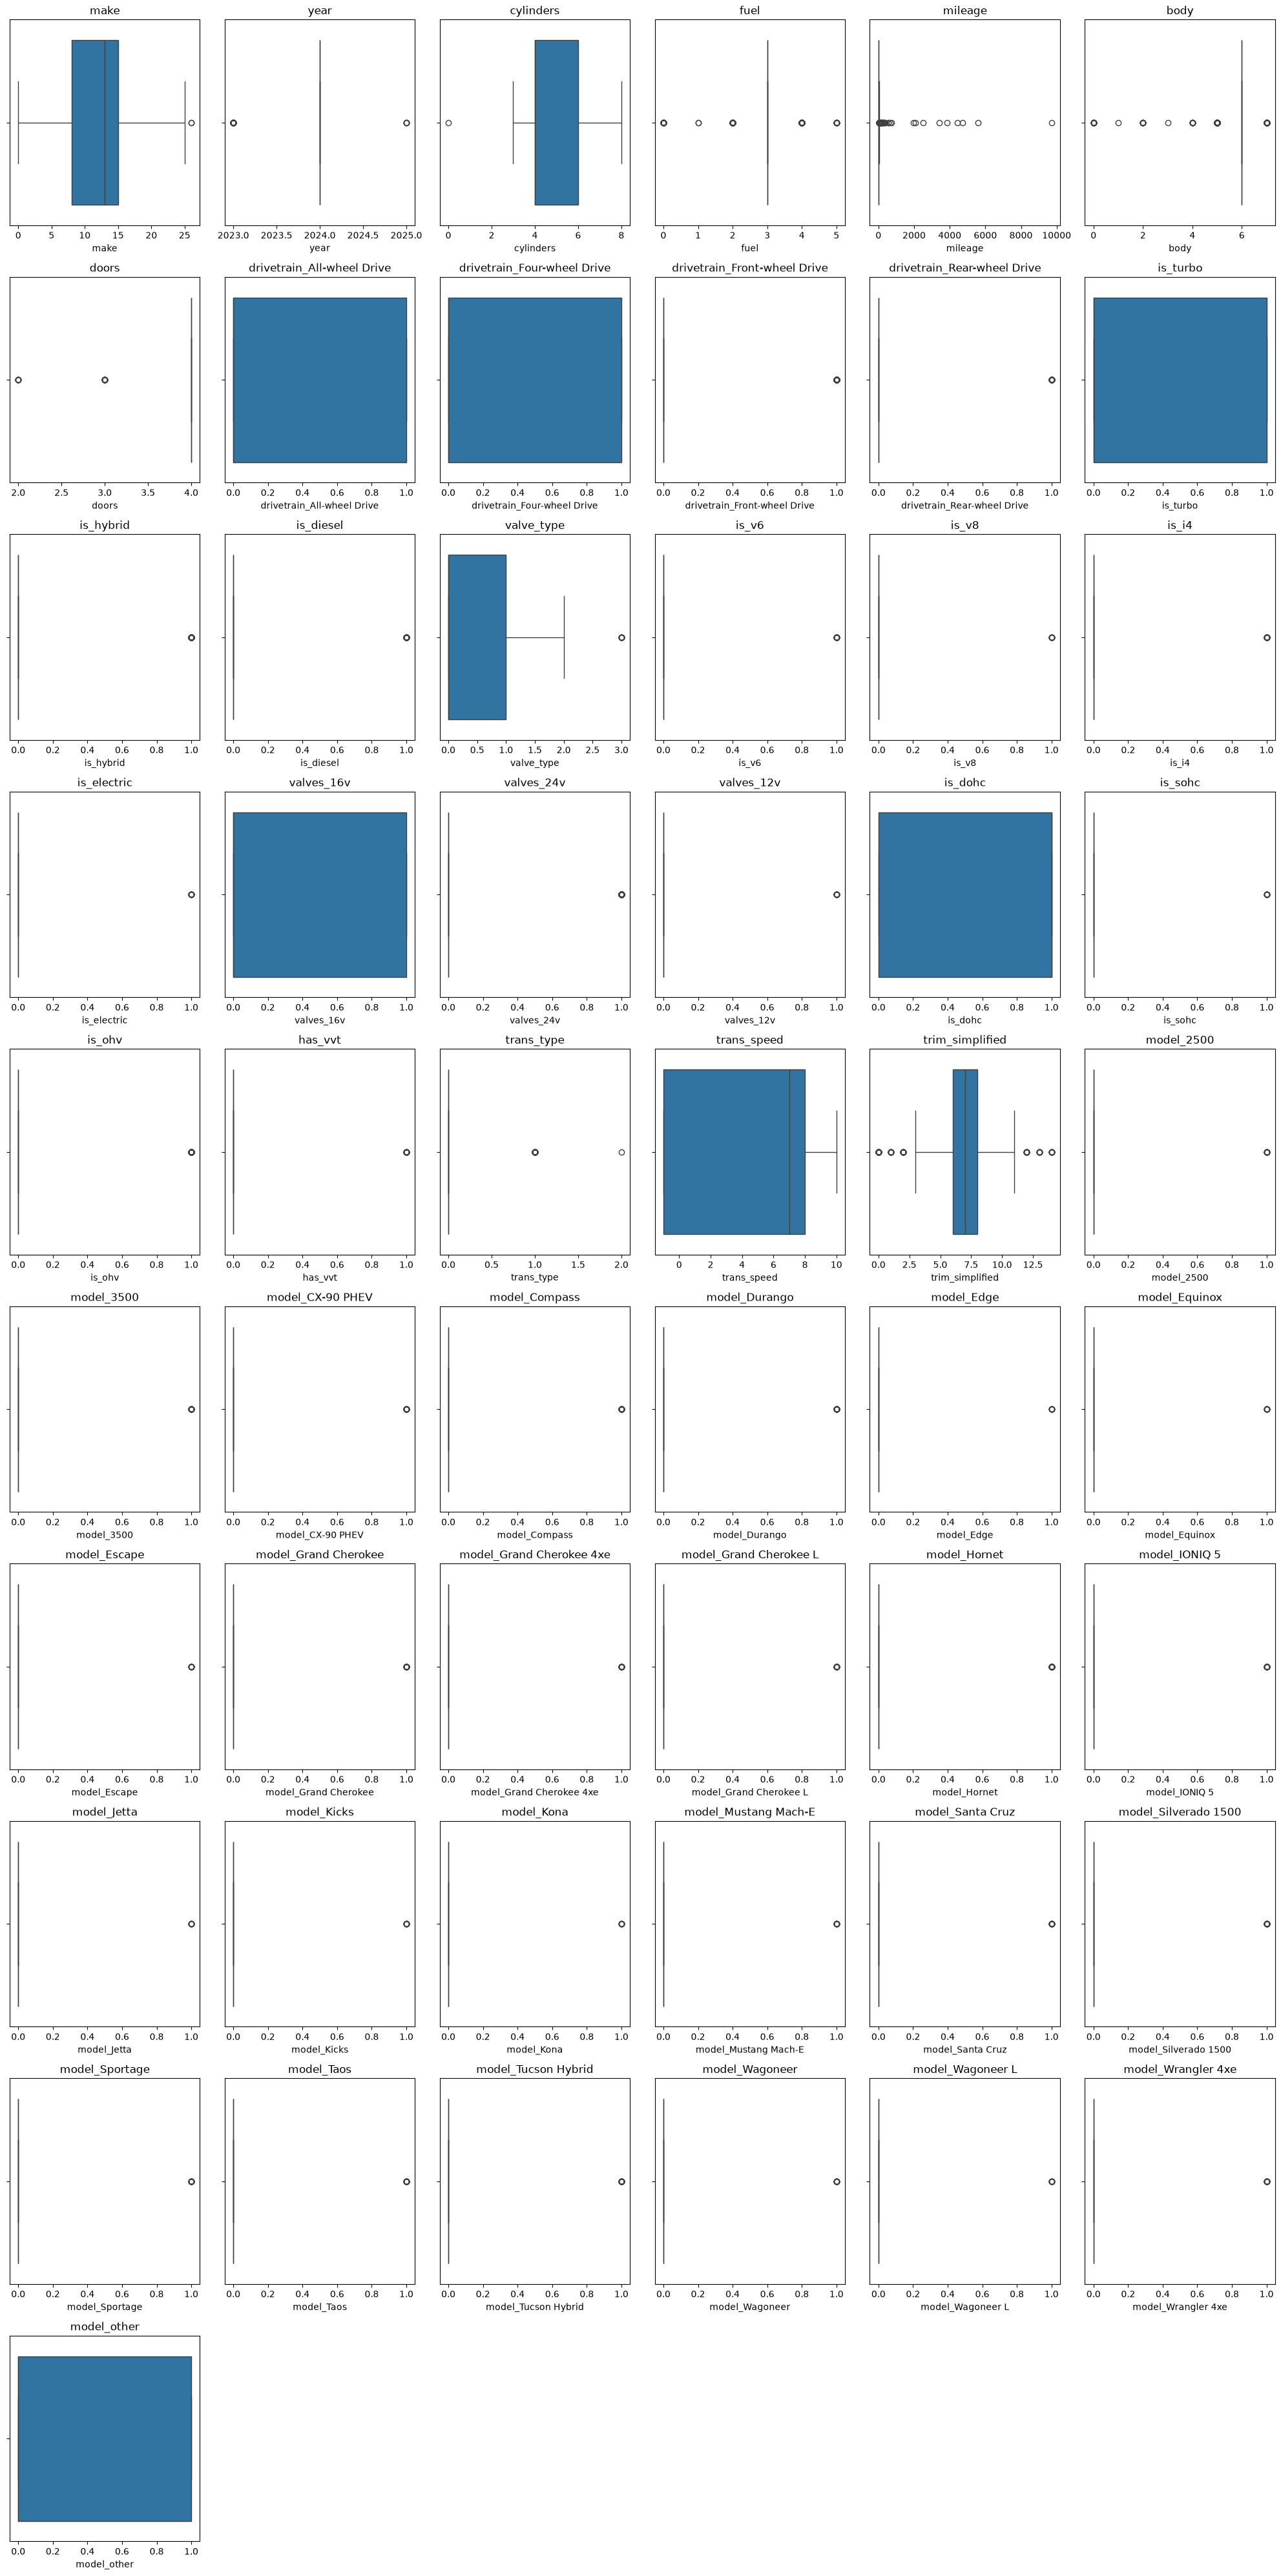

In [62]:
n_cols = 6
n_rows = math.ceil(len(x_scaled.columns) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
ax = ax.flatten()
for i, col in enumerate(x_scaled.columns):
    sns.boxplot(x=x_train[col], ax=ax[i])
    ax[i].set_title(col)
for j in range(len(x_scaled.columns), len(ax)):
    ax[j].set_visible(False)
plt.tight_layout()
plt.show()

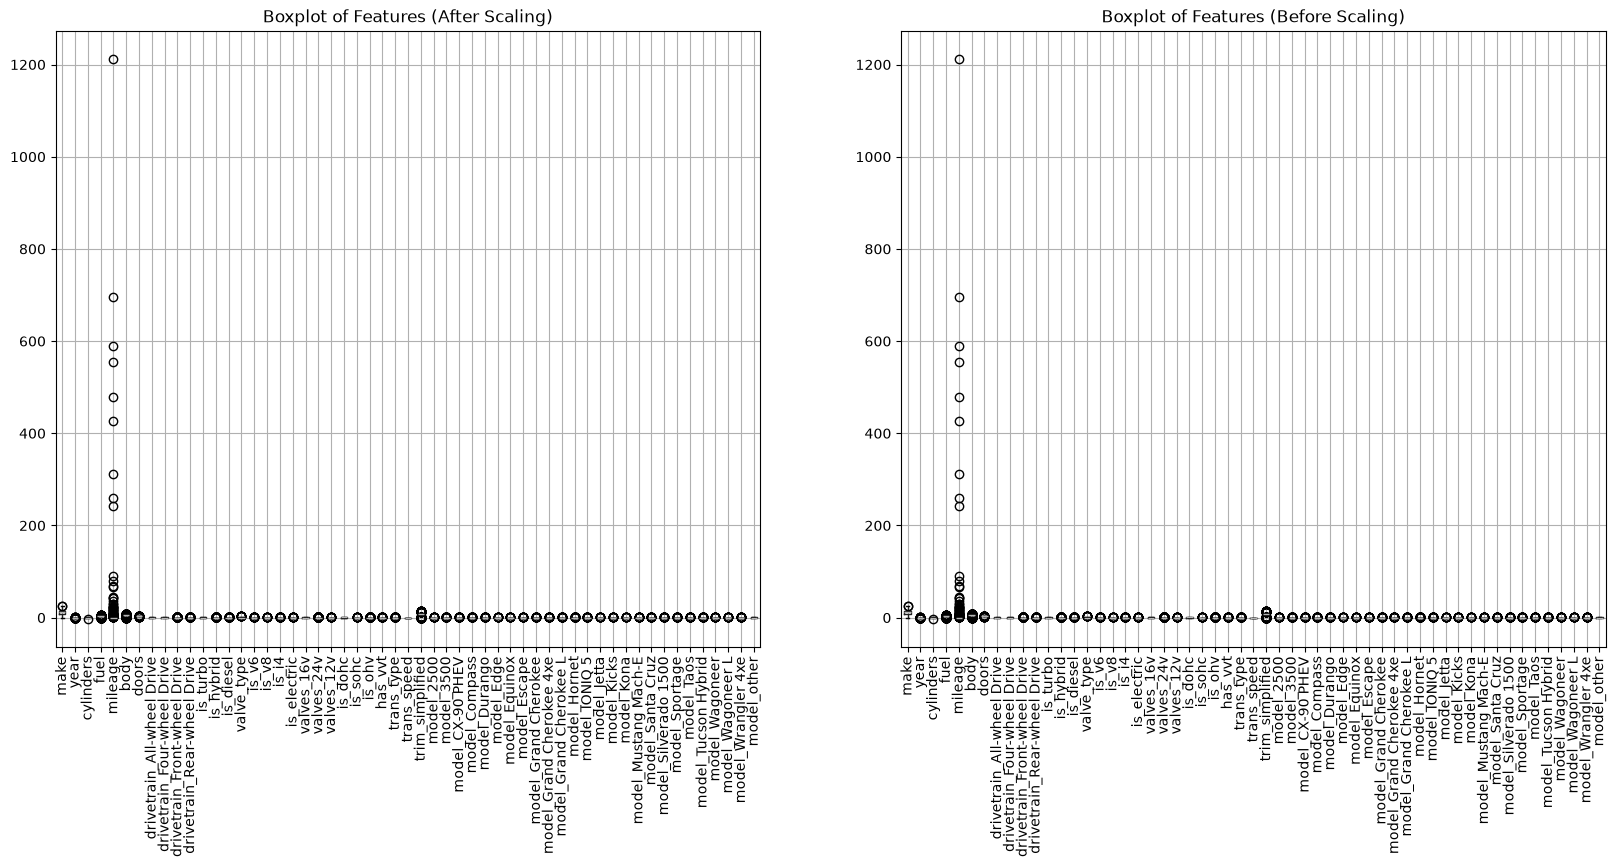

In [60]:
plt.figure(figsize=(20,8))
plt.subplot(121)
x_scaled.boxplot(figsize=(16, 6), rot=90)
plt.title("Boxplot of Features (After Scaling)")
plt.subplot(122)
x_scaled.boxplot(figsize=(16, 6), rot=90)
plt.title("Boxplot of Features (Before Scaling)");

# Variance Threshold 
* Varaince  : هو انا بشوف Features بتاعتي هل بها تنوع ولا لا 
* لو الارقام عالية يبقي في تنوع كبير ، ولو هي صغيرة يبقي فيها تنوع قليل 

In [64]:
x_scaled.var().sort_values(ascending=False)

mileage                         4285.931425
make                              38.002072
trim_simplified                    8.614655
body                               1.631880
fuel                               0.938399
valve_type                         0.676256
cylinders                          0.461835
drivetrain_All-wheel Drive         0.248251
valves_16v                         0.245696
is_turbo                           0.240370
model_other                        0.231249
trans_speed                        0.222018
drivetrain_Four-wheel Drive        0.221925
is_dohc                            0.210753
valves_24v                         0.133568
drivetrain_Front-wheel Drive       0.122476
is_hybrid                          0.110880
is_ohv                             0.101854
year                               0.080693
doors                              0.073637
drivetrain_Rear-wheel Drive        0.066333
is_diesel                          0.065197
trans_type                      

In [67]:
# Apply Specific Threshold 
from sklearn.feature_selection import VarianceThreshold 
selector = VarianceThreshold(threshold=0.1)
x_scaled_reduced = selector.fit_transform(x_scaled)
x_scaled_reduced

array([[12.        ,  0.        ,  4.        , ..., -0.11111111,
        11.        ,  0.        ],
       [22.        ,  1.        ,  0.        , ..., -0.88888889,
         7.        ,  0.        ],
       [ 5.        ,  0.        ,  3.        , ..., -0.88888889,
         7.        ,  0.        ],
       ...,
       [15.        ,  0.        ,  3.        , ...,  0.11111111,
         7.        ,  0.        ],
       [22.        ,  2.        ,  3.        , ...,  0.11111111,
         7.        ,  0.        ],
       [ 5.        ,  0.        ,  3.        , ..., -0.88888889,
         7.        ,  0.        ]], shape=(757, 18))

In [73]:
print(f"The Shaped of X Scaled Reduced is ==> {x_scaled_reduced.shape}",
      f"\n The Shaped of X scaled are ==> {x_scaled.shape}")
print("======================================================")
cols = selector.get_feature_names_out()
print("The Columns of selector \n", cols)
print("======================================================")
x_scaled_reduced = pd.DataFrame(x_scaled_reduced,columns=cols,index=x_train.index)
x_scaled_reduced

The Shaped of X Scaled Reduced is ==> (757, 18) 
 The Shaped of X scaled are ==> (757, 55)
The Columns of selector 
 ['make' 'cylinders' 'fuel' 'mileage' 'body' 'drivetrain_All-wheel Drive'
 'drivetrain_Four-wheel Drive' 'drivetrain_Front-wheel Drive' 'is_turbo'
 'is_hybrid' 'valve_type' 'valves_16v' 'valves_24v' 'is_dohc' 'is_ohv'
 'trans_speed' 'trim_simplified' 'model_other']


,make,cylinders,fuel,mileage,body,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,is_turbo,is_hybrid,valve_type,valves_16v,valves_24v,is_dohc,is_ohv,trans_speed,trim_simplified,model_other
111,12.0,0.0,4.0,-0.375,6.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,-0.111111,11.0,0.0
78,22.0,1.0,0.0,0.625,5.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,-0.888889,7.0,0.0
578,5.0,0.0,3.0,-0.625,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.888889,7.0,0.0
893,11.0,0.0,3.0,-1.000,6.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,-0.888889,1.0,1.0
84,14.0,1.0,3.0,0.000,6.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.111111,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,14.0,0.0,3.0,-0.875,6.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.888889,5.0,0.0
278,19.0,0.0,5.0,0.125,6.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.888889,8.0,0.0
911,15.0,0.0,3.0,-0.875,6.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.111111,7.0,0.0
455,22.0,2.0,3.0,-1.000,5.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.111111,7.0,0.0


In [75]:
#Check some columns 
print(x_train['is_v8'].value_counts(normalize=True))
print("==============================================")
print(x_train['is_i4'].value_counts(normalize=True))

is_v8
0    0.988111
1    0.011889
Name: proportion, dtype: float64
is_i4
0    0.963012
1    0.036988
Name: proportion, dtype: float64


In [76]:
cols

array(['make', 'cylinders', 'fuel', 'mileage', 'body',
       'drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive',
       'drivetrain_Front-wheel Drive', 'is_turbo', 'is_hybrid',
       'valve_type', 'valves_16v', 'valves_24v', 'is_dohc', 'is_ohv',
       'trans_speed', 'trim_simplified', 'model_other'], dtype=object)

In [77]:
# Correlation Matrix 
df1 = pd.concat([x_scaled,y_train],axis=1)
df1

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,price
111,12.0,0.0,0.0,4.0,-0.375,6.0,4.0,1.0,0.0,0.0,0.0,1,1,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,-0.111111,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,35864.0
78,22.0,0.0,1.0,0.0,0.625,5.0,4.0,0.0,1.0,0.0,0.0,1,0,1,1.0,0,0,0,0,0,1,0,0,0,1,0,0.0,-0.888889,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63223.0
578,5.0,0.0,0.0,3.0,-0.625,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,-0.888889,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30955.0
893,11.0,1.0,0.0,3.0,-1.000,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,1.0,-0.888889,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,38305.0
84,14.0,0.0,1.0,3.0,0.000,6.0,4.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1,0,0.0,0.111111,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49390.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,14.0,0.0,0.0,3.0,-0.875,6.0,4.0,0.0,1.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,-0.888889,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28867.0
278,19.0,0.0,0.0,5.0,0.125,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,1,1,0,0,1,0,0,0,0.0,-0.888889,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54949.0
911,15.0,0.0,0.0,3.0,-0.875,6.0,4.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,0.111111,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,40250.0
455,22.0,0.0,2.0,3.0,-1.000,5.0,4.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,1,0,0,0,0,1,0,0.0,0.111111,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61865.0


price          1.000000
cylinders      0.403678
mileage        0.052687
year          -0.000648
trans_speed   -0.035530
doors         -0.088785
Name: price, dtype: float64


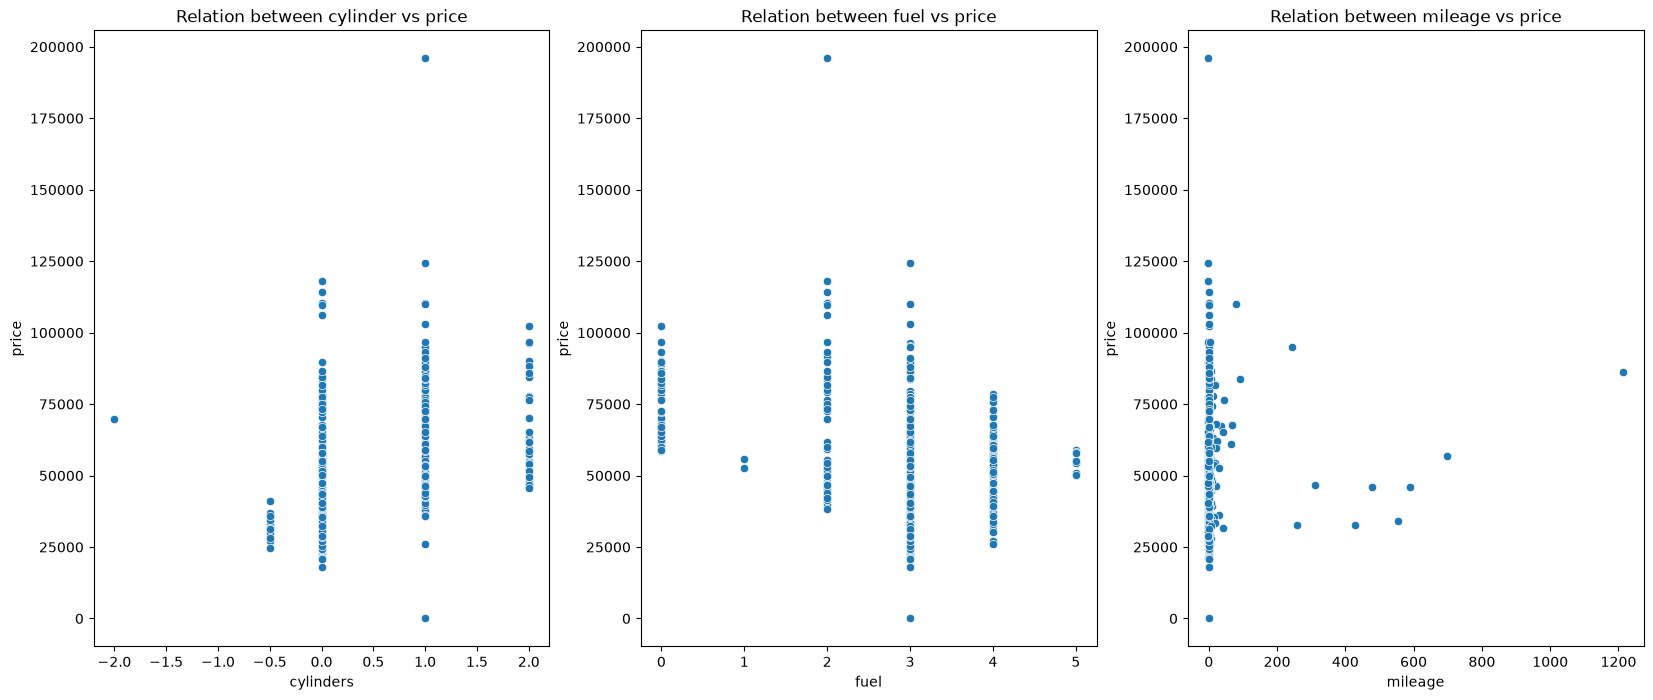

In [78]:
cols = ['year', 'cylinders', 'mileage', 'doors', 'trans_speed', 'price']
corr_matrix = df1[cols].corr()['price'].sort_values(ascending=False)
print(corr_matrix)
print("================================================================")
plt.figure(figsize=(20,8))
plt.subplot(131)
sns.scatterplot(data=df1,x='cylinders',y='price')
plt.title('Relation between cylinder vs price')

plt.subplot(132)
sns.scatterplot(data=df1,x='fuel',y='price')
plt.title('Relation between fuel vs price')

plt.subplot(133)
sns.scatterplot(data=df1,x='mileage',y='price')
plt.title('Relation between mileage vs price');

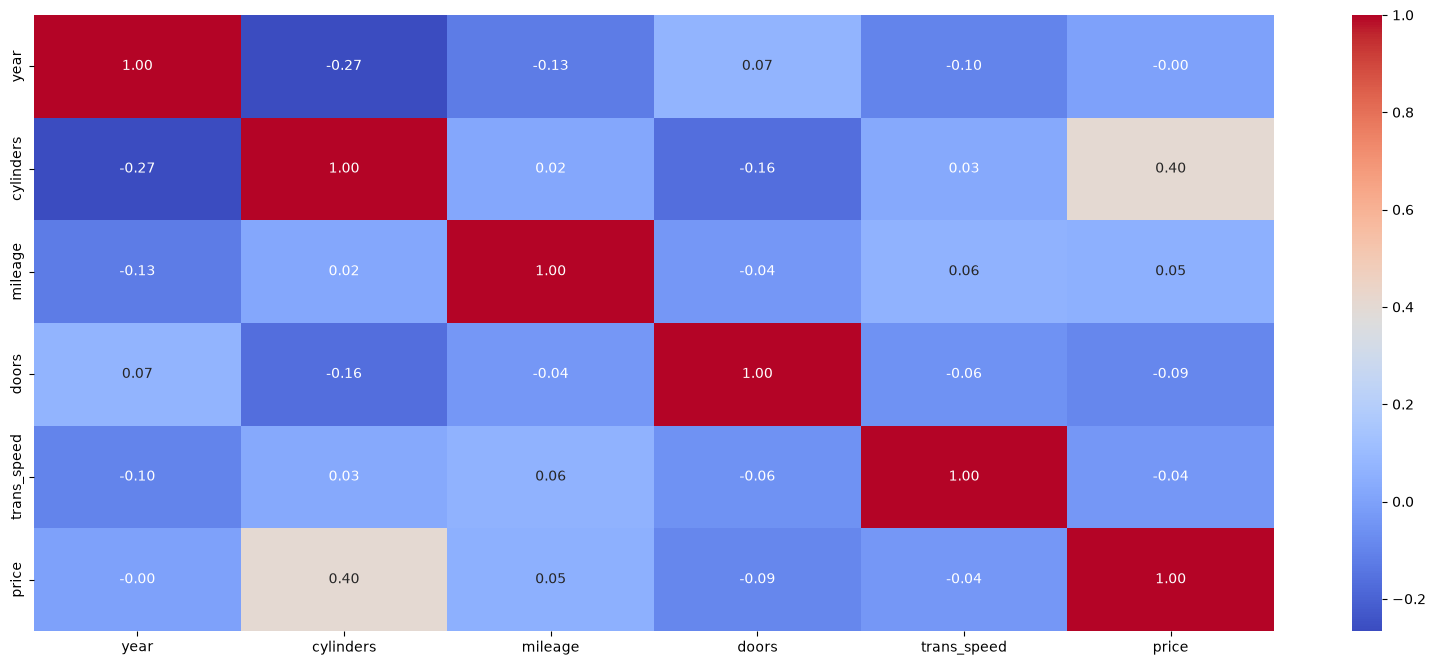

In [80]:
plt.figure(figsize=(20,8))
sns.heatmap(data=df1[cols].corr(),annot=True,fmt='.2f',cmap="coolwarm");

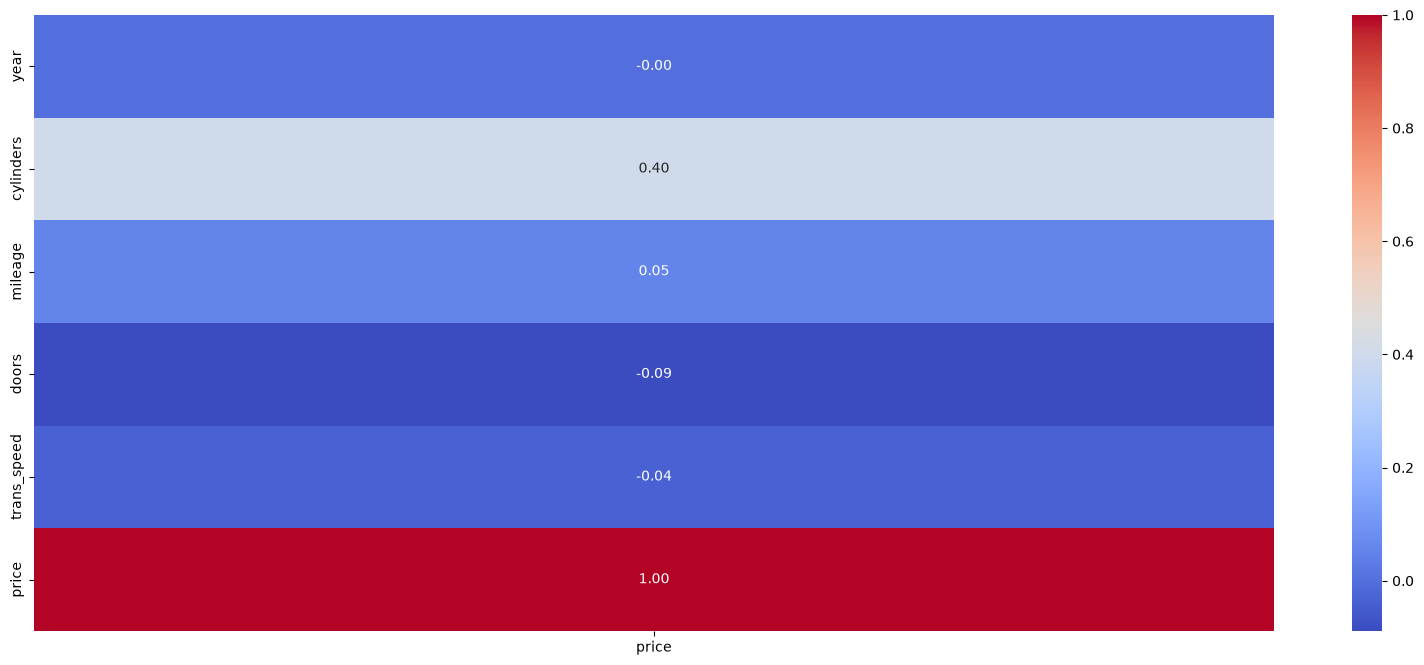

In [81]:
plt.figure(figsize=(20, 8))
sns.heatmap(data=df1[cols].corr()[['price']], annot=True, fmt=".2f", cmap="coolwarm");

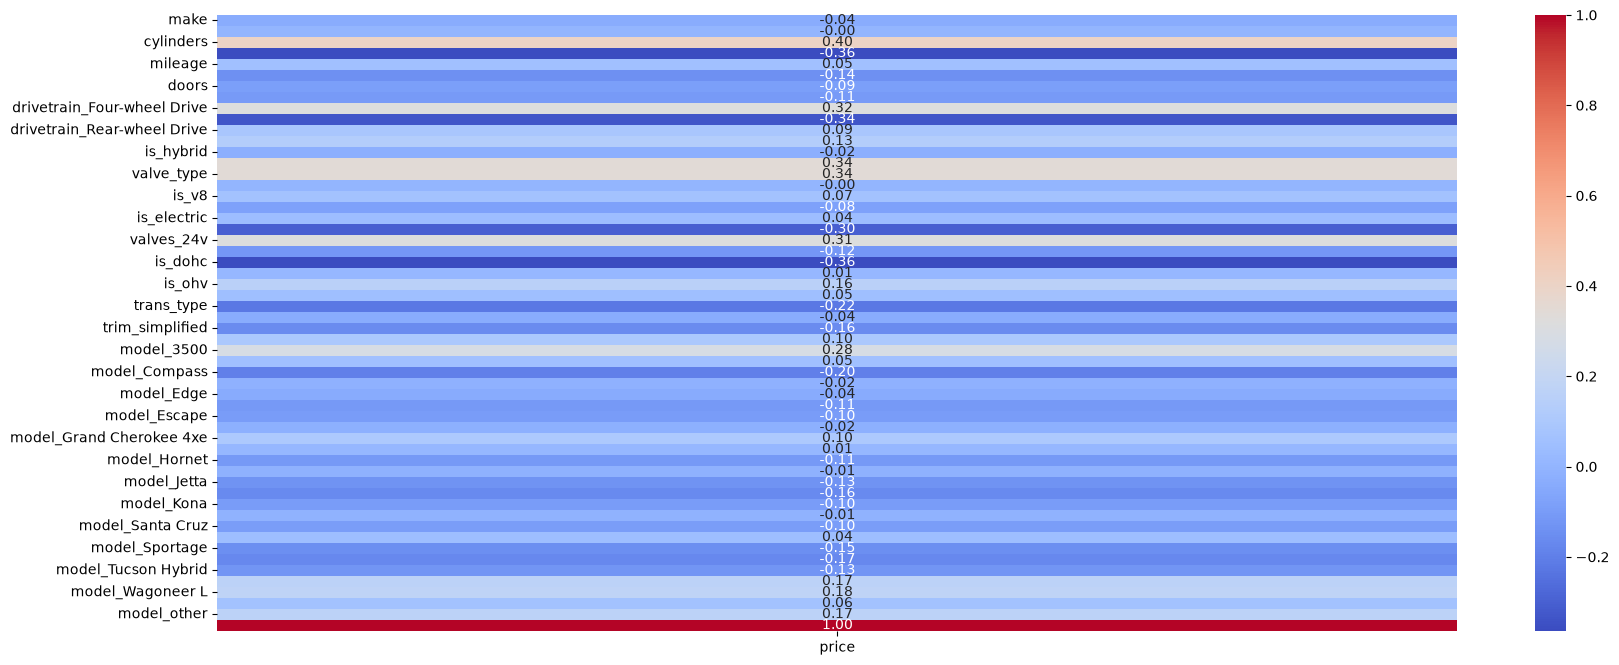

In [82]:
# Don't show this
plt.figure(figsize=(20, 8))
sns.heatmap(data=df1.corr()[['price']], annot=True, fmt=".2f", cmap="coolwarm");

In [83]:
corr_matrix

price          1.000000
cylinders      0.403678
mileage        0.052687
year          -0.000648
trans_speed   -0.035530
doors         -0.088785
Name: price, dtype: float64

In [84]:
corr_matrix[corr_matrix.abs() > 0.1].drop('price')

cylinders    0.403678
Name: price, dtype: float64

In [85]:
threshold = 0.1

# Get features with |correlation| > threshold (excluding 'price' itself)
selected_features = corr_matrix[corr_matrix.abs() > threshold]
selected_features_corr = selected_features.drop('price')  # Remove the target itself
selected_features_corr

cylinders    0.403678
Name: price, dtype: float64

In [86]:
len(selected_features_corr)

1

In [89]:
cols.pop(1)

'cylinders'

In [90]:
cols.pop(-1)

'price'

In [91]:
selected_features_corr = x_scaled.drop(columns=cols)
selected_features_corr

,make,cylinders,fuel,body,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trim_simplified,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other
111,12.0,0.0,4.0,6.0,1.0,0.0,0.0,0.0,1,1,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
78,22.0,1.0,0.0,5.0,0.0,1.0,0.0,0.0,1,0,1,1.0,0,0,0,0,0,1,0,0,0,1,0,0.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
578,5.0,0.0,3.0,6.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
893,11.0,0.0,3.0,6.0,1.0,0.0,0.0,0.0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
84,14.0,1.0,3.0,6.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1,0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,14.0,0.0,3.0,6.0,0.0,1.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
278,19.0,0.0,5.0,6.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,1,1,0,0,1,0,0,0,0.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
911,15.0,0.0,3.0,6.0,1.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
455,22.0,2.0,3.0,5.0,0.0,1.0,0.0,0.0,0,0,0,1.0,0,0,0,0,1,0,0,0,0,1,0,0.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
from sklearn.feature_selection import RFE 
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
rfe = RFE(estimator= model,n_features_to_select=14)
rfe.fit(x_scaled,y_train)
selected_features_linear = x_scaled.columns[rfe.support_]
print(f"The Top Features are ==> {selected_features_linear}",
      f"\n\n The Selected Features Columns are ==> {selected_features_corr.columns}")

The Top Features are ==> Index(['cylinders', 'fuel', 'drivetrain_Front-wheel Drive', 'is_hybrid',
       'is_diesel', 'is_electric', 'model_CX-90 PHEV', 'model_Escape',
       'model_Grand Cherokee 4xe', 'model_Mustang Mach-E', 'model_Wagoneer',
       'model_Wagoneer L', 'model_Wrangler 4xe', 'model_other'],
      dtype='str') 

 The Selected Features Columns are ==> Index(['make', 'cylinders', 'fuel', 'body', 'drivetrain_All-wheel Drive',
       'drivetrain_Four-wheel Drive', 'drivetrain_Front-wheel Drive',
       'drivetrain_Rear-wheel Drive', 'is_turbo', 'is_hybrid', 'is_diesel',
       'valve_type', 'is_v6', 'is_v8', 'is_i4', 'is_electric', 'valves_16v',
       'valves_24v', 'valves_12v', 'is_dohc', 'is_sohc', 'is_ohv', 'has_vvt',
       'trans_type', 'trim_simplified', 'model_2500', 'model_3500',
       'model_CX-90 PHEV', 'model_Compass', 'model_Durango', 'model_Edge',
       'model_Equinox', 'model_Escape', 'model_Grand Cherokee',
       'model_Grand Cherokee 4xe', 'model_Grand

In [97]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
rfe=RFE(estimator=model,n_features_to_select=14)
rfe.fit(x_scaled,y_train)
selected_features_tree = x_scaled.columns[rfe.support_]
print(f"The Top Features are ==> {selected_features_tree}")

The Top Features are ==> Index(['make', 'cylinders', 'fuel', 'mileage', 'body',
       'drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive',
       'drivetrain_Front-wheel Drive', 'is_turbo', 'trans_speed',
       'trim_simplified', 'model_Wagoneer L', 'model_Wrangler 4xe',
       'model_other'],
      dtype='str')
